In [1]:
import os
import sys
sys.path.append('../..')
from pykml import parser
import pandas as pd
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from bs4 import BeautifulSoup
import numpy as np
import xarray as xr
import cmocean
import cimf as c

plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.cursive'] = ['Helvetica-Oblique']
plt.rcParams['pdf.fonttype'] = 42

crs = ccrs.PlateCarree()
plotcrs = ccrs.LambertConformal(central_longitude=-58.8, central_latitude=15,standard_parallels=(15,15))

In [2]:
ds = xr.open_mfdataset("../../../Data/LambertGrid/629x989interped/fc2017090512+???.nc", concat_dim="valid_time", combine="nested", decode_timedelta=True)

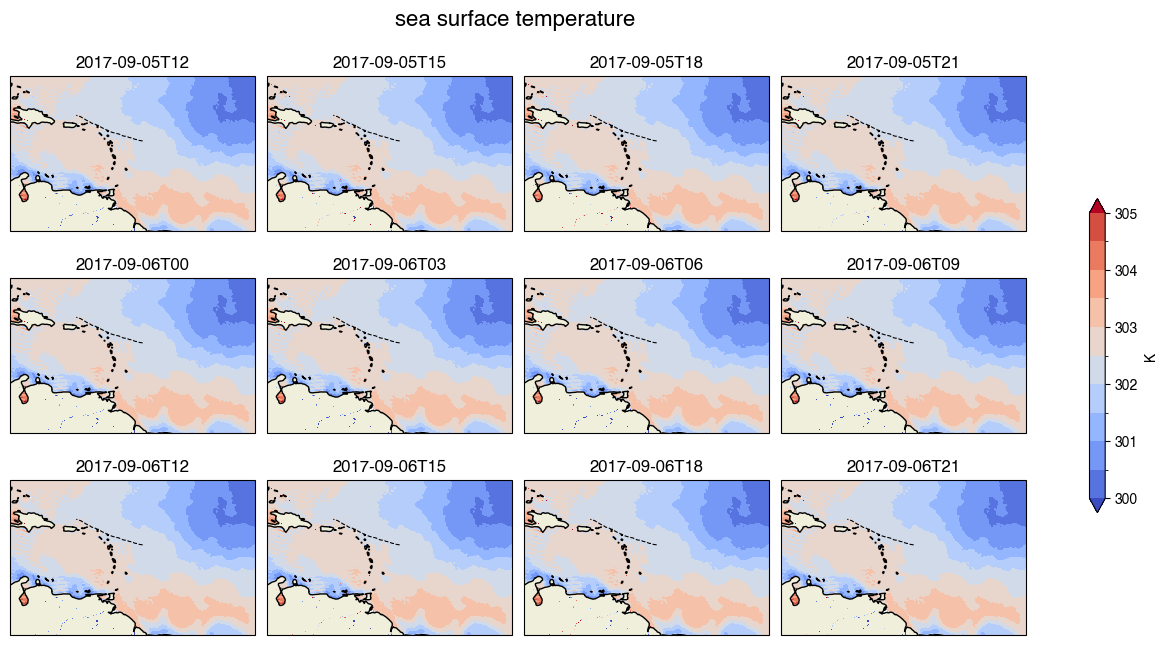

In [3]:
Z = ds.t0m.where(~ds.lsm.astype('bool')).isel(valid_time=range(0,36,3))

plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='coolwarm', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    #vmin=300, vmax=305,
    levels=np.arange(300,305.1,0.5)
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle("sea surface temperature", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))
    ax.add_feature(cfeature.LAND)

2017-09-06T08:00:00.000000000


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


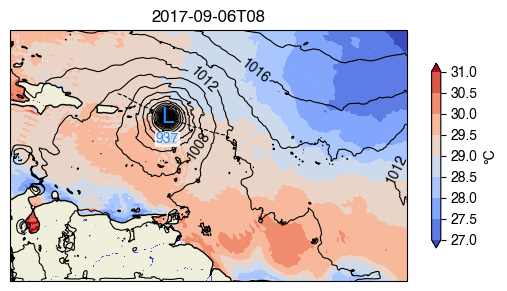

In [4]:
step = 20
Z = ds.t0m.where(~ds.lsm.astype('bool')).isel(valid_time=step) - 273.15
Z.attrs['units'] = '°C'
print(str(Z.valid_time.data))

crs = ccrs.PlateCarree()
ax = plt.axes(projection=plotcrs)
#ax.tricontourf(Z.longitude.stack(xy=('x','y')), Z.latitude.stack(xy=('x','y')), Z.stack(xy=('x','y')), cmap='coolwarm', transform=crs, levels=np.arange(27,31.1,0.5))
plots = Z.plot(
    cmap='coolwarm', transform=crs,
    antialiased=True, 
    x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    # levels=np.arange(300,305.1,0.5),
    levels=np.arange(27,31.1,0.5),
    rasterized=True,
)
psllevs = np.arange(932,1025,2)
psl = (ds.psl/100).isel(valid_time=step).plot.contour(ax=ax, x='longitude', y='latitude', transform=crs, colors='k', linewidths=0.8, levels=psllevs)
xc = ds.xc.isel(valid_time=step)
yc = ds.yc.isel(valid_time=step)
ax.text(ds.longitude.sel(y=yc, x=xc), ds.latitude.sel(y=yc, x=xc), 'L', 
        ha='center', va='center', size=16, weight=1000, c='dodgerblue', transform=crs)
ax.text(ds.longitude.sel(y=yc, x=xc), ds.latitude.sel(y=yc, x=xc)-1, f"{(ds.psl/100).isel(valid_time=step).min().compute().item():.0f}", 
        ha='center', va='top', size=10, weight=1000, c='dodgerblue', transform=crs, bbox=dict(fc='w', ec='w', alpha=0.8, pad=0.15))
ax.clabel(psl, levels=range(1008,1025,4))
ax.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--')
ax.set_title('')
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.set_title(pd.to_datetime(Z.valid_time.data).strftime('%Y-%m-%dT%H'))
ax.figure.savefig('SST.MSLP.pdf', format='pdf', bbox_inches='tight', dpi=300, transparent=False)

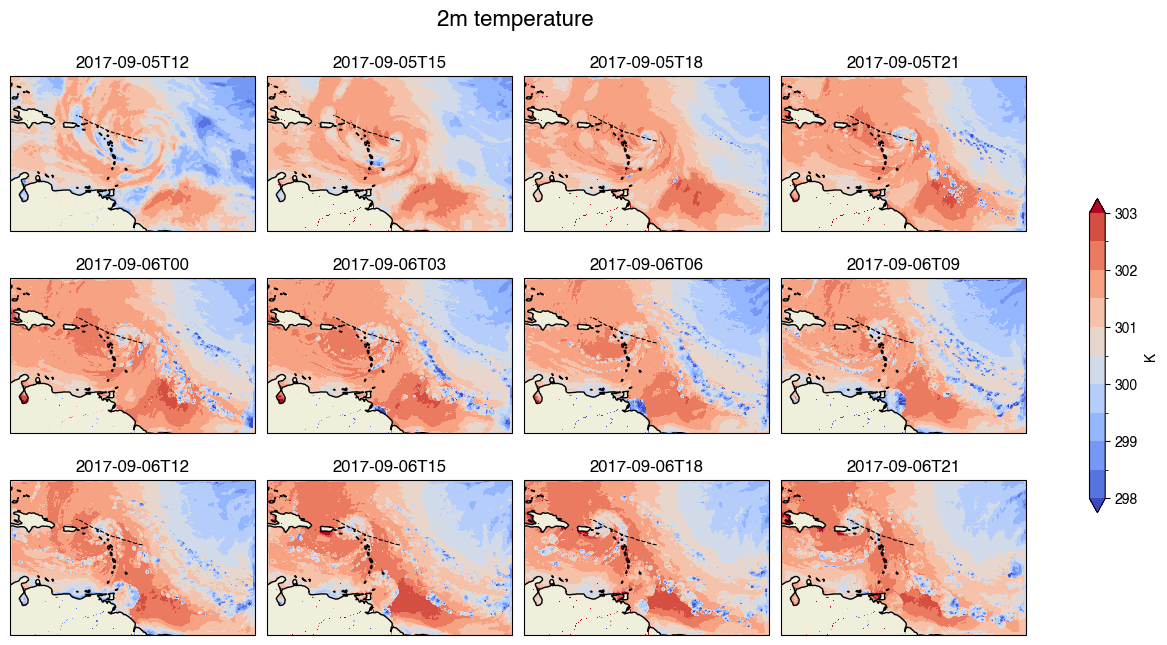

In [5]:
Z = ds.t2m.where(~ds.lsm.astype('bool')).isel(valid_time=range(0,36,3))

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='coolwarm', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    #vmin=298, vmax=303,
    levels=np.arange(298,303.1,0.5), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle("2m temperature", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))
    ax.add_feature(cfeature.LAND)

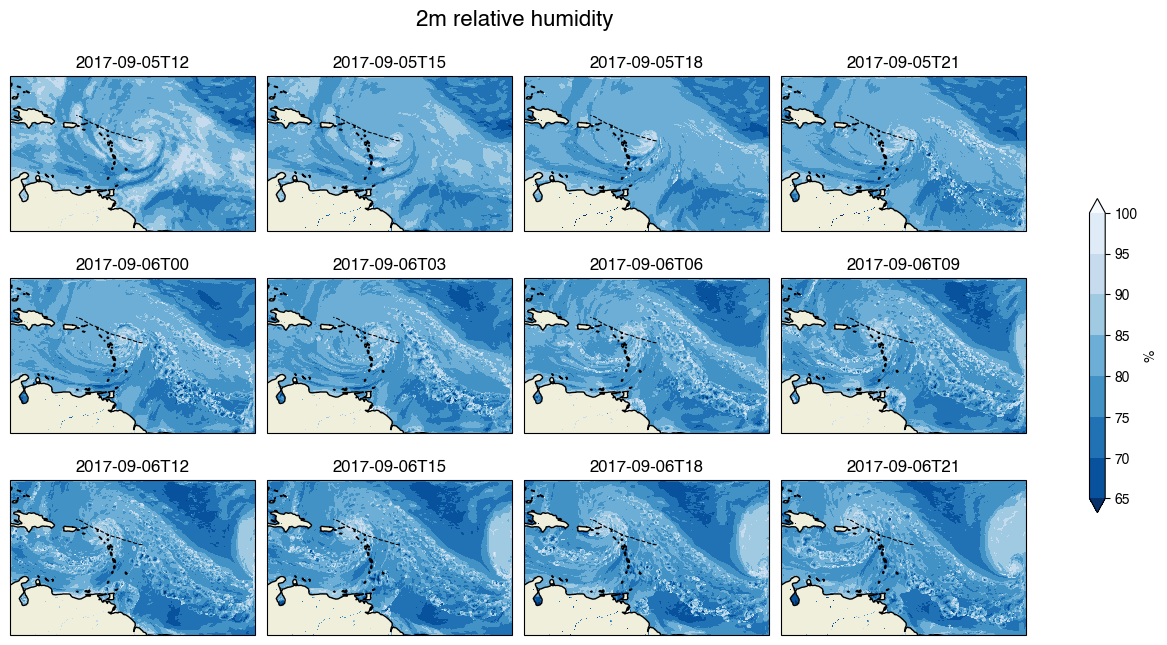

In [6]:
Z = ds.r2m.where(~ds.lsm.astype('bool')).isel(valid_time=range(0,36,3)) * 100
Z.attrs['units'] = '%' # attrs get deleted with multiplication by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='Blues_r', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    #vmin=65,
    levels=range(65,101,5), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle("2m relative humidity", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))
    ax.add_feature(cfeature.LAND)

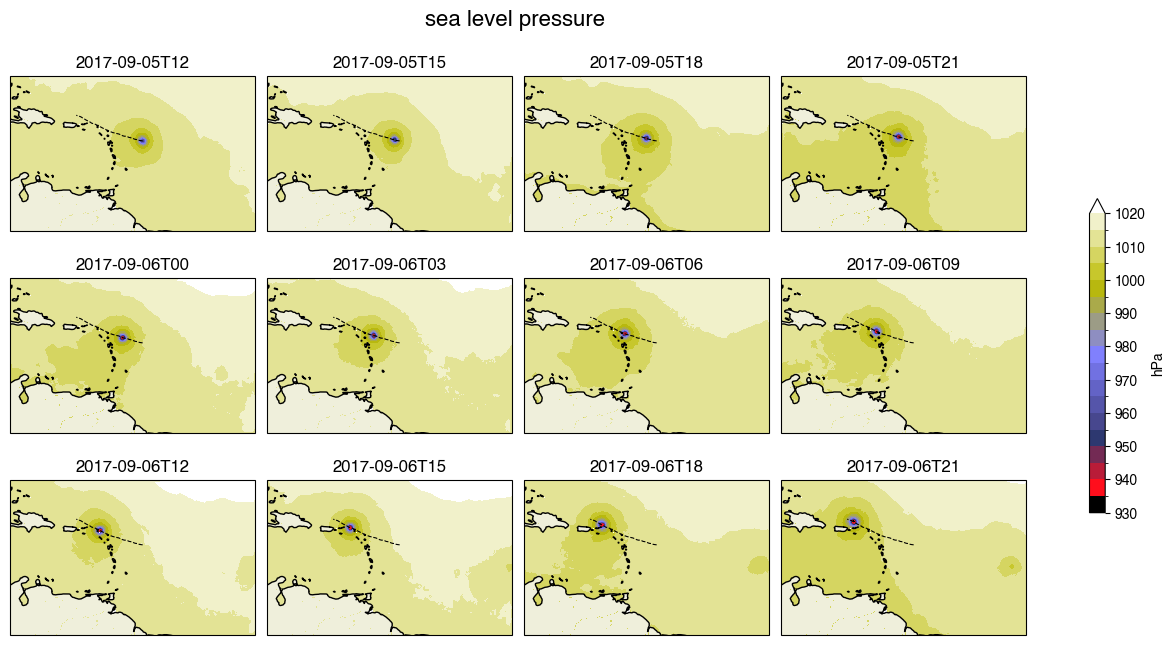

In [7]:
Z = ds.psl.where(~ds.lsm.astype('bool')).isel(valid_time=range(0,36,3)) / 100
Z.attrs['units'] = 'hPa' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='gist_stern', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    #vmin=935, vmax=1015,
    levels=range(930,1021,5), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle("sea level pressure", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))
    ax.add_feature(cfeature.LAND)

In [8]:
TH1 = 320 # these numbers roughly match 400-700 hPa
TH2 = 350

# calculate weights along theta dimension for mass-weighted means
dtheta = ds.theta.diff('theta', label='lower').sel(theta=slice(TH1,TH2)) # theta coordinate increment
dp = dtheta/ds.dtdp.sel(theta=slice(TH1,TH2)) # 3D increment in pressure
weights = dp/dp.mean('theta') # local pressure thickness compared to average level pressure thickness

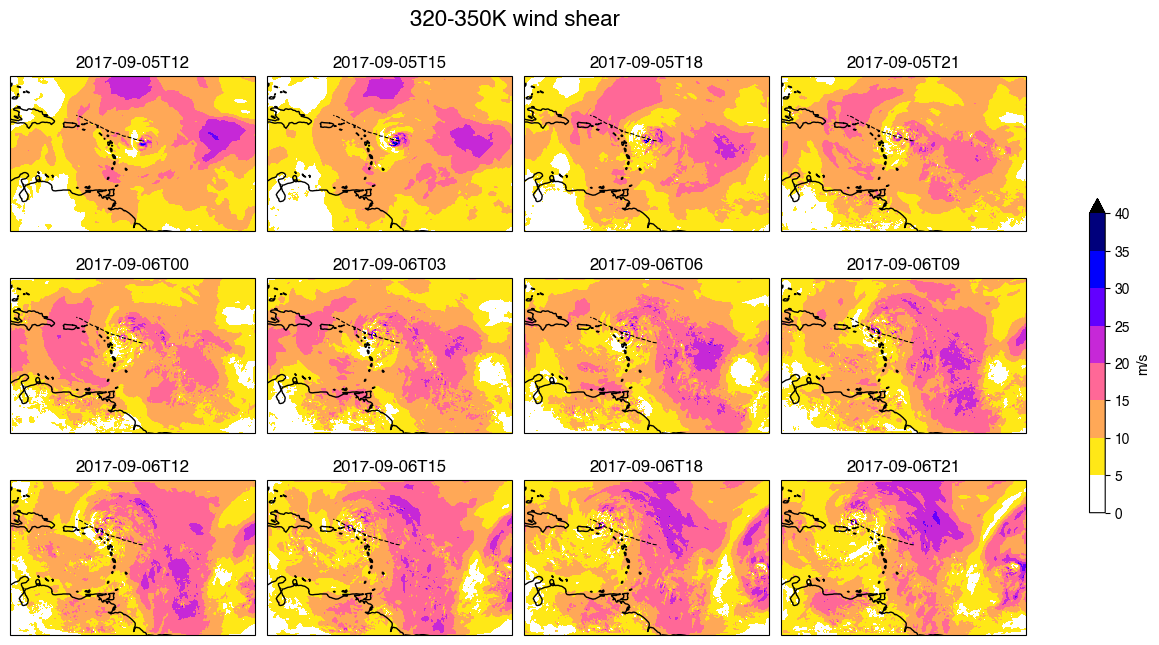

In [9]:
Z = np.sqrt((ds.u.sel(theta=TH1) - ds.u.sel(theta=TH2))**2 + (ds.v.sel(theta=TH1) - ds.v.sel(theta=TH2))**2).isel(valid_time=range(0,36,3))
Z.attrs['units'] = 'm/s' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='gnuplot2_r', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(0,45,5), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle(f"{TH1}-{TH2}K wind shear", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

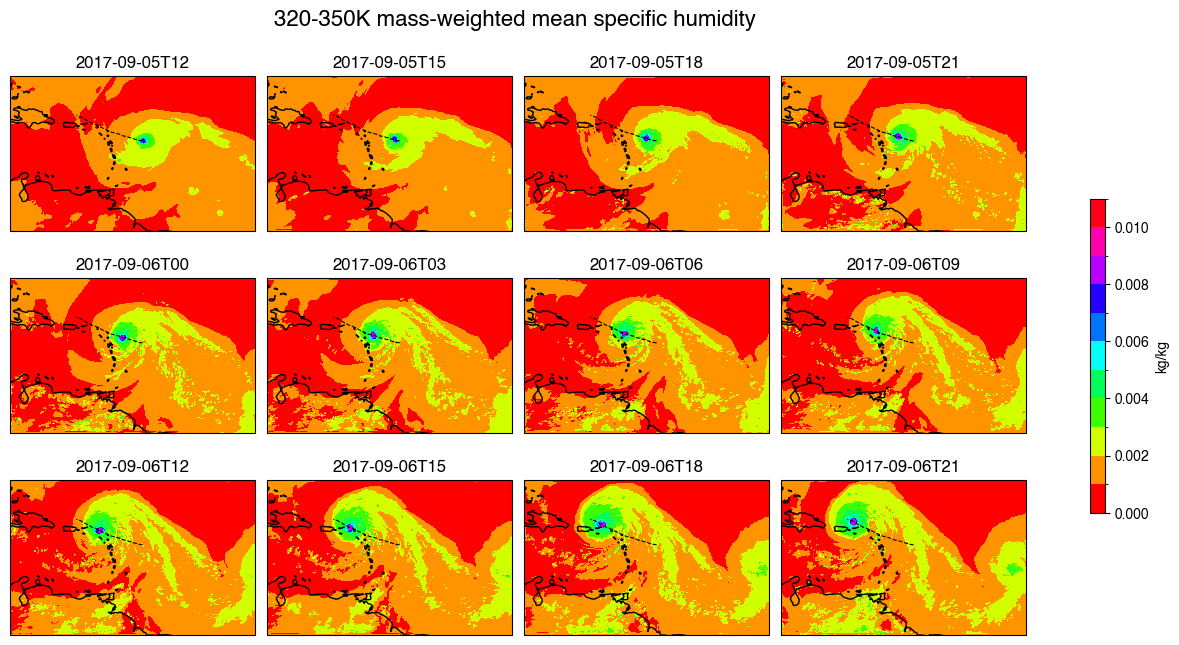

In [10]:
Z = (ds.q.sel(theta=slice(TH1,TH2))*weights).mean('theta', keep_attrs=True).isel(valid_time=range(0,36,3))
Z.attrs['units'] = 'kg/kg' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='hsv', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=np.arange(0,0.012,0.001), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle(f"{TH1}-{TH2}K mass-weighted mean specific humidity", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

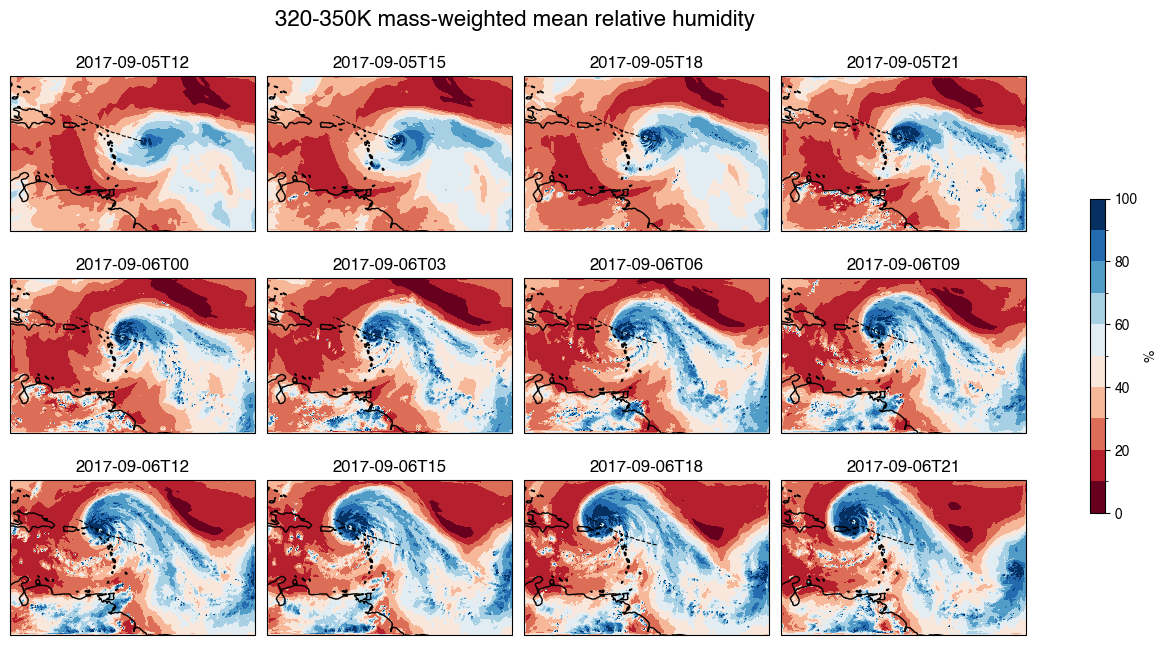

In [11]:
Tc = ds.t - 273.15 # T in celsius
Pvsat = 610.78 * np.exp(17.27*Tc/(Tc+237.3)) # Tetens formula
Pv = ds.q * ds.pres / (0.622 + ds.q) # vapor pressure in Pa
RH = (100 * Pv/Pvsat).clip(max=100)
Z = (RH.sel(theta=slice(TH1,TH2))*weights).mean('theta', keep_attrs=True).isel(valid_time=range(0,36,3)).clip(max=99.999)
Z.attrs['units'] = '%'

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='RdBu', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(0,101,10), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle(f"{TH1}-{TH2}K mass-weighted mean relative humidity", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

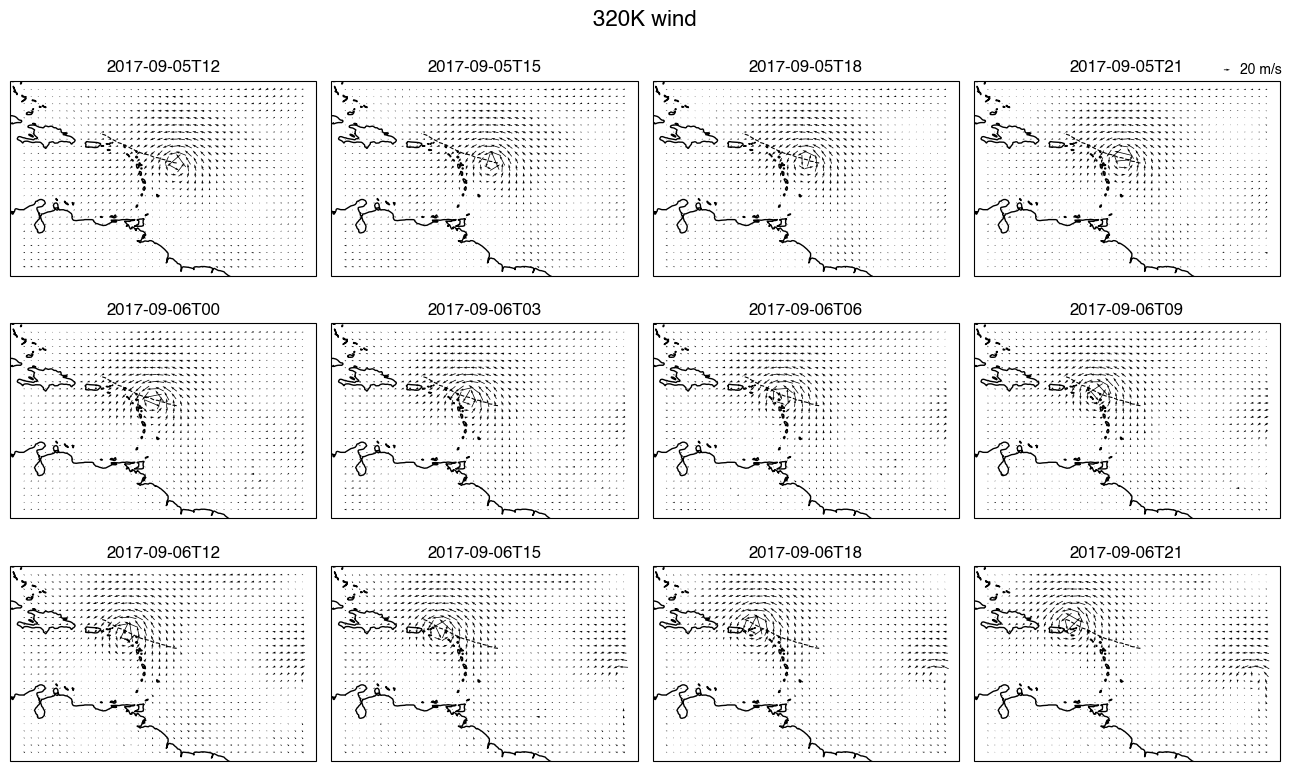

In [12]:
TH = 320
Z = ds.sel(theta=TH).isel(x=range(0,988, 25), y=range(0,629,25), valid_time=range(0,36,3))

crs = ccrs.PlateCarree()
plots = Z.plot.quiver(
    x='longitude', y='latitude', u='u', v='v',
    col='valid_time', col_wrap=4, transform=crs, 
    subplot_kws={'projection':plotcrs}, scale=1000, add_guide=False
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.6)
plots.fig.suptitle(f"{TH}K wind", fontsize=16, va='bottom', y=1, x=0.5)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

qk = ax.quiverkey(ax.get_children()[0], 0.95, 0.95, 20, r'20 m/s', labelpos='E', coordinates='figure')

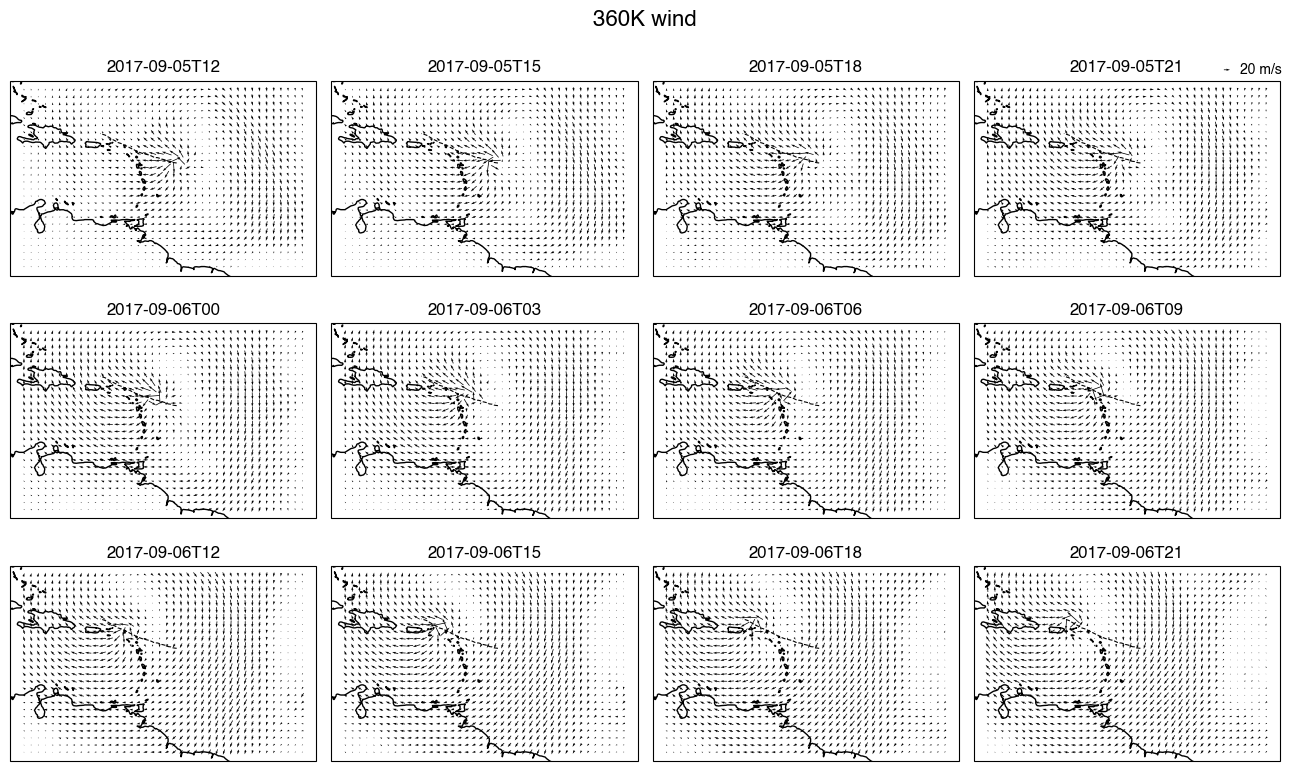

In [13]:
TH = 360
Z = ds.sel(theta=TH).isel(x=range(0,988, 25), y=range(0,629,25), valid_time=range(0,36,3))

crs = ccrs.PlateCarree()
plots = Z.plot.quiver(
    x='longitude', y='latitude', u='u', v='v',
    col='valid_time', col_wrap=4, transform=crs, 
    subplot_kws={'projection':plotcrs}, scale=1000, add_guide=False
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
plots.fig.set_figheight(plots.fig.get_figwidth()*0.6)
plots.fig.suptitle(f"{TH}K wind", fontsize=16, va='bottom', y=1, x=0.5)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

qk = ax.quiverkey(ax.get_children()[0], 0.95, 0.95, 20, r'20 m/s', labelpos='E', coordinates='figure')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


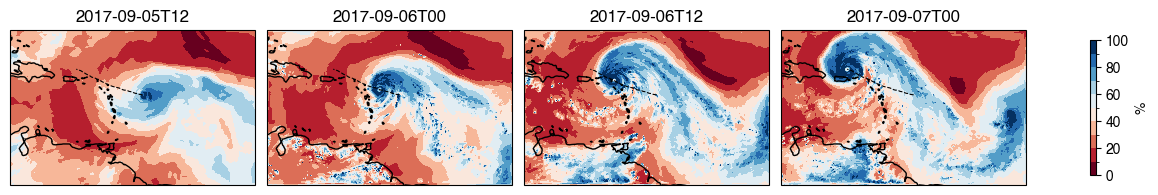

In [14]:
Tc = ds.t - 273.15 # T in celsius
Pvsat = 610.78 * np.exp(17.27*Tc/(Tc+237.3)) # Tetens formula
Pv = ds.q * ds.pres / (0.622 + ds.q) # vapor pressure in Pa
RH = (100 * Pv/Pvsat).clip(max=100)
Z = (RH.sel(theta=slice(TH1,TH2))*weights).mean('theta', keep_attrs=True).isel(valid_time=range(0,37,12)).clip(max=99.999)
Z.attrs['units'] = '%'

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='RdBu', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(0,101,10), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
#plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
#plots.fig.suptitle(f"{TH1}-{TH2}K mass-weighted mean relative humidity", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

plots.fig.savefig('RH.pdf', format='pdf', bbox_inches='tight', dpi=300, transparent=False)

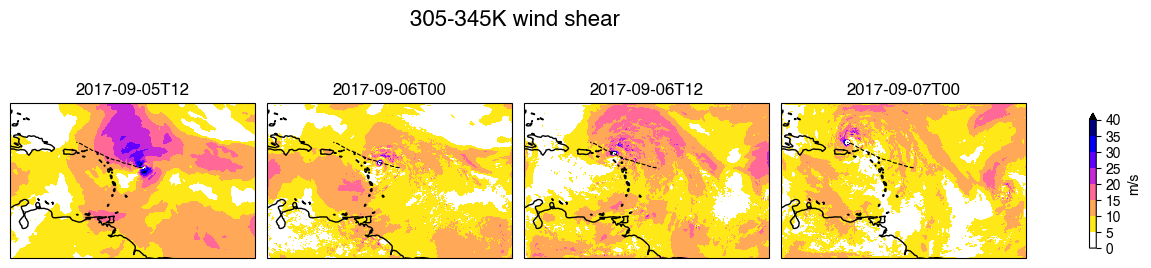

In [15]:
TH1 = 305 # these numbers roughly match 200-850hPa
TH2 = 345
Z = np.sqrt((ds.u.sel(theta=TH1) - ds.u.sel(theta=TH2))**2 + (ds.v.sel(theta=TH1) - ds.v.sel(theta=TH2))**2).isel(valid_time=range(0,37,12))
Z.attrs['units'] = 'm/s' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='gnuplot2_r', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(0,45,5), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
#plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle(f"{TH1}-{TH2}K wind shear", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

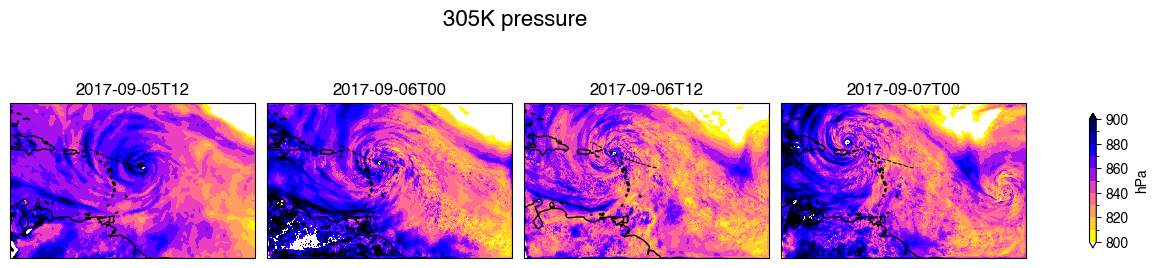

In [16]:
TH = 305
Z = ds.pres.sel(theta=TH).isel(valid_time=range(0,37,12)) / 100
Z.attrs['units'] = 'hPa' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='gnuplot2_r', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(800,901,10), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
#plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle(f"{TH}K pressure", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

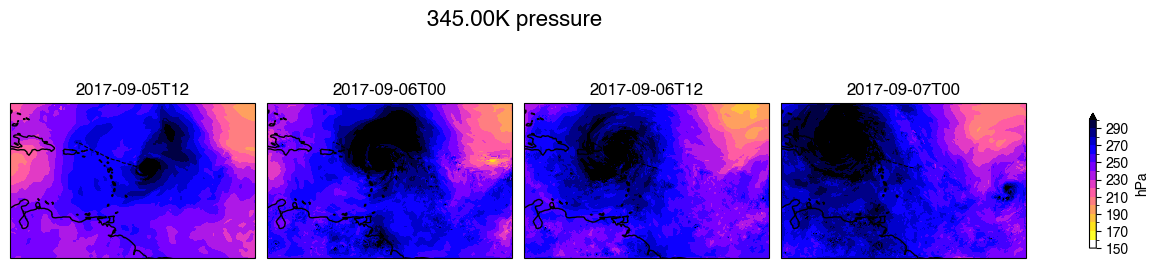

In [17]:
TH = 345
Z = ds.pres.sel(theta=TH, method='nearest').isel(valid_time=range(0,37,12)) / 100
Z.attrs['units'] = 'hPa' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='gnuplot2_r', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(150,301,10), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
#plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
plots.fig.suptitle(f"{Z.theta:.2f}K pressure", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

In [18]:
from numba import float64, guvectorize

@guvectorize(
    "(float32[:], float32[:], float32[:], float32[:])",
    " (n), (n), (m) -> (m)",
    nopython=True,
)
def interp1d_gu(f, x, xi, out):
    """Interpolate field f(x) to xi in ln(x) coordinates."""
    i, imax, x0, f0 = 0, len(xi), x[0], f[0]
    while xi[i]<x0 and i < imax:
        out[i] = np.nan      
        i = i + 1 
    for x1,f1 in zip(x[1:], f[1:]):
        while xi[i] <= x1 and i < imax:
            out[i] = (f1-f0)/np.log(x1/x0)*np.log(xi[i]/x0)+f0
            i = i + 1
        x0, f0 = x1, f1
    while i < imax:
        out[i] = np.nan
        i = i + 1


def xr_interp(data, p, newp):
    print(f"xr_interp: {data.name}")
    interped = xr.apply_ufunc(
        interp1d_gu,  # first the function
        data,  # now arguments in the order expected by 'interp1_np'
        p,  # as above
        newp,  # as above
        input_core_dims=[['hybrid'], ['hybrid'], ['p']],  # list with one entry per arg
        output_core_dims=[['p']],  # returned data has one dimension
        exclude_dims=set(('hybrid',)),  # dimensions allowed to change size. Must be a set!
        dask="parallelized",
        output_dtypes=[
            data.dtype
        ],  # one per output; could also be float or np.dtype("float64")
    ).persist()
    interped['p'] = newp

    return interped

In [19]:
ds = xr.open_mfdataset("../../../Data/LambertGrid/629x989/fc2017090512+???.nc", concat_dim="valid_time", combine="nested", decode_timedelta=True)
ds['pres'] = (ds.a + ds.b * ds.p0m).astype('float32')

In [20]:
up = xr_interp(ds.u, ds.pres, np.array([20000,85000], dtype='float32'))
vp = xr_interp(ds.v, ds.pres, np.array([20000,85000], dtype='float32'))

xr_interp: u
xr_interp: v


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


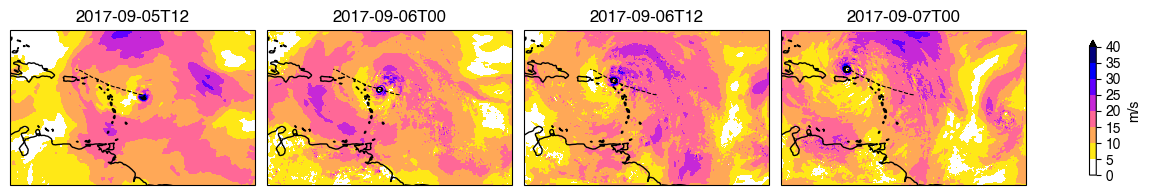

In [21]:
Z = np.sqrt((up.isel(p=0)-up.isel(p=1))**2 + (vp.isel(p=0)-vp.isel(p=1))**2).isel(valid_time=range(0,37,12))
Z.attrs['units'] = 'm/s' # attrs get deleted with division by 100, must restore here

crs = ccrs.PlateCarree()
plots = Z.plot(
    col='valid_time', col_wrap=4, cmap='gnuplot2_r', transform=crs, 
    subplot_kws={'projection':plotcrs}, x='longitude', y='latitude',
    cbar_kwargs={'shrink':0.5, 'label':Z.units},
    levels=range(0,45,5), rasterized=True,
)
plots.map(lambda: plt.plot(ds.longitude.sel(x=ds.xc, y=ds.yc), ds.latitude.sel(x=ds.xc, y=ds.yc), transform=crs, c='k', lw=0.8, ls='--'))
plots.set_titles('{value}')
#plots.fig.set_figheight(plots.fig.get_figwidth()*0.5)
#plots.fig.suptitle(f"{int(up.p[0]/100)}-{int(up.p[1]/100)}hPa wind shear", fontsize=16, va='bottom', y=1, x=0.4)
for i,ax in enumerate(plots.axs.flat):
    ax.coastlines()
    ax.set_title(pd.to_datetime(Z.valid_time.data[i]).strftime('%Y-%m-%dT%H'))

plots.fig.savefig('VWS.pdf', format='pdf', bbox_inches='tight', dpi=300, transparent=False)